# Questão 5 - Análise de clientes

In [20]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import duckdb
from IPython.display import Image, display

### Caminho base do projeto

In [21]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


Carregando os dados em um dataframe Pandas para melhor visulização. 

In [22]:
DATA_PATH = BASE_PATH / "data"

RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"
INTERMEDIATE_PATH = DATA_PATH / "intermediate"
MARTS_PATH = DATA_PATH / "marts"

SQL_PATH = BASE_PATH / "sql"
IMAGES_PATH = BASE_PATH / "imagens"

Análise com o Pandas

Para fazer essa análise usei os arquivos arquivos csv que preparei para uma camada staging.

Como se trata de uma análise de comportamento de compras, vou apresentar os clientes apenas pelo id_cliente aqui. 

Acredito que informações mais detalhadas sobre os clientes, são mais apropriada para um dashboard interno. (respeitando a LGPD)

In [23]:
df_vendas = pd.read_csv(STAGING_PATH / "stg_vendas.csv")
df_produtos = pd.read_csv(STAGING_PATH / "stg_produtos.csv")

In [24]:
df_vendas.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda
0,1230,17,91,4,512566.80,2023-01-01
1,2300,30,95,9,596858.40,2023-01-01
2,3131,28,130,13,53873.00,2023-01-01
3,4212,9,96,6,402538.75,2023-01-01
4,4294,7,44,5,51332.30,2023-01-01


In [25]:
df_produtos.head()

,nome_produto,preco_base_produto,id_produto,categoria_produto
0,Transponder AIS Maré Magnum,33122.52,1,eletronicos
1,Transponder Furuno Marlin,13998.15,2,eletronicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletronicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletronicos
4,Piloto Automático Furuno Storm,23669.01,5,eletronicos


In [26]:
df = df_vendas.merge(df_produtos, on="id_produto", how="left")
df.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,nome_produto,preco_base_produto,categoria_produto
0,1230,17,91,4,512566.80,2023-01-01,Motor Elétrico Tohatsu Zenith Oceanic 113HP,134886.02,propulsao
1,2300,30,95,9,596858.40,2023-01-01,Motor Diesel Honda Leviathan 133HP,69808.04,propulsao
2,3131,28,130,13,53873.00,2023-01-01,Boia de Arqueamento Delta Zen Boost Vortex,4144.09,ancoragem
3,4212,9,96,6,402538.75,2023-01-01,Motor de Popa Tohatsu Boost Swift 126HP,70620.84,propulsao
4,4294,7,44,5,51332.30,2023-01-01,GPS Simrad Zen Hydra Peak,10806.84,eletronicos


In [27]:
df_clientes_metricas = df.groupby("id_cliente").agg(
    faturamento_total=("valor_total", "sum"),
    frequencia=("id_venda", "count"),
    ticket_medio=("valor_total", "mean"),
    diversidade=("categoria_produto", "nunique")
).reset_index()

df_clientes_metricas.head()

,id_cliente,faturamento_total,frequencia,ticket_medio,diversidade
0,1,51669494.40,200,258347.472000,3
1,2,67717055.25,225,300964.690000,3
2,3,60878498.10,212,287162.726887,3
3,4,59332571.15,228,260230.575219,3
4,5,61071262.70,210,290815.536667,3


In [28]:
df_elite = (
    df_clientes_metricas[df_clientes_metricas["diversidade"] >= 3]
    .sort_values(by=["ticket_medio", "id_cliente"], ascending=[False, True])
    .head(10)
)

df_top = df[df["id_cliente"].isin(df_elite["id_cliente"])]

In [29]:
df_top.head(10)


,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,nome_produto,preco_base_produto,categoria_produto
2,3131,28,130,13,53873.00,2023-01-01,Boia de Arqueamento Delta Zen Boost Vortex,4144.09,ancoragem
3,4212,9,96,6,402538.75,2023-01-01,Motor de Popa Tohatsu Boost Swift 126HP,70620.84,propulsao
13,1238,42,149,4,4654.00,2023-01-02,Cabo de Nylon Bruce Core,1163.62,ancoragem
18,4770,28,124,4,14326.00,2023-01-02,Corrente Delta Axis,3769.93,ancoragem
20,7777,26,25,11,126721.45,2023-01-02,Rádio Lowrance Nitro Thrust Barracuda,12126.46,eletronicos
24,9643,22,65,14,357808.00,2023-01-02,Motor de Popa Torqeedo Nautic Swift 223HP,25557.70,propulsao
26,4034,5,86,8,710775.75,2023-01-02,Motor Diesel Volvo Helix Evo Force 144HP,93523.13,propulsao
33,6966,28,74,15,1298378.00,2023-01-03,Motor de Popa Honda Torque 228HP,86558.56,propulsao
34,8172,46,72,12,1136177.20,2023-01-03,Motor de Popa Volvo Hydro Dash 256HP,99664.64,propulsao
42,4071,28,84,13,564510.00,2023-01-03,Motor de Popa Torqeedo Zenith Peak Thrust 212HP,43423.88,propulsao


In [30]:
df_categoria = (
    df_top
    .groupby("categoria_produto")
    .agg(qtd_total=("quantidade", "sum"))
    .reset_index()
    .sort_values(by="qtd_total", ascending=False)
)

df_categoria

,categoria_produto,qtd_total
2,propulsao,6429
0,ancoragem,6003
1,eletronicos,5376


Questão 5.1 - Código SQL
Código calculando:

• O Ticket Médio e a Diversidade de categorias por cliente.

• A identificação e filtro dos 1 0 clientes "Fiéis" (maior Ticket
Médio entre aqueles com diversidade ›= 3 categorias).

• A categoria mais vendida (em quantidade total de
itens) considerando apenas o histórico desses 10
clientes.

Link para a query:


In [31]:
query_path = SQL_PATH / "5_1_codigo.sql"

with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

print(f"Link para a query: {SQL_PATH / '5_1_codigo.sql'}")


Link para a query: /Users/richardgomes/lh-nautical-data-project/sql/5_1_codigo.sql


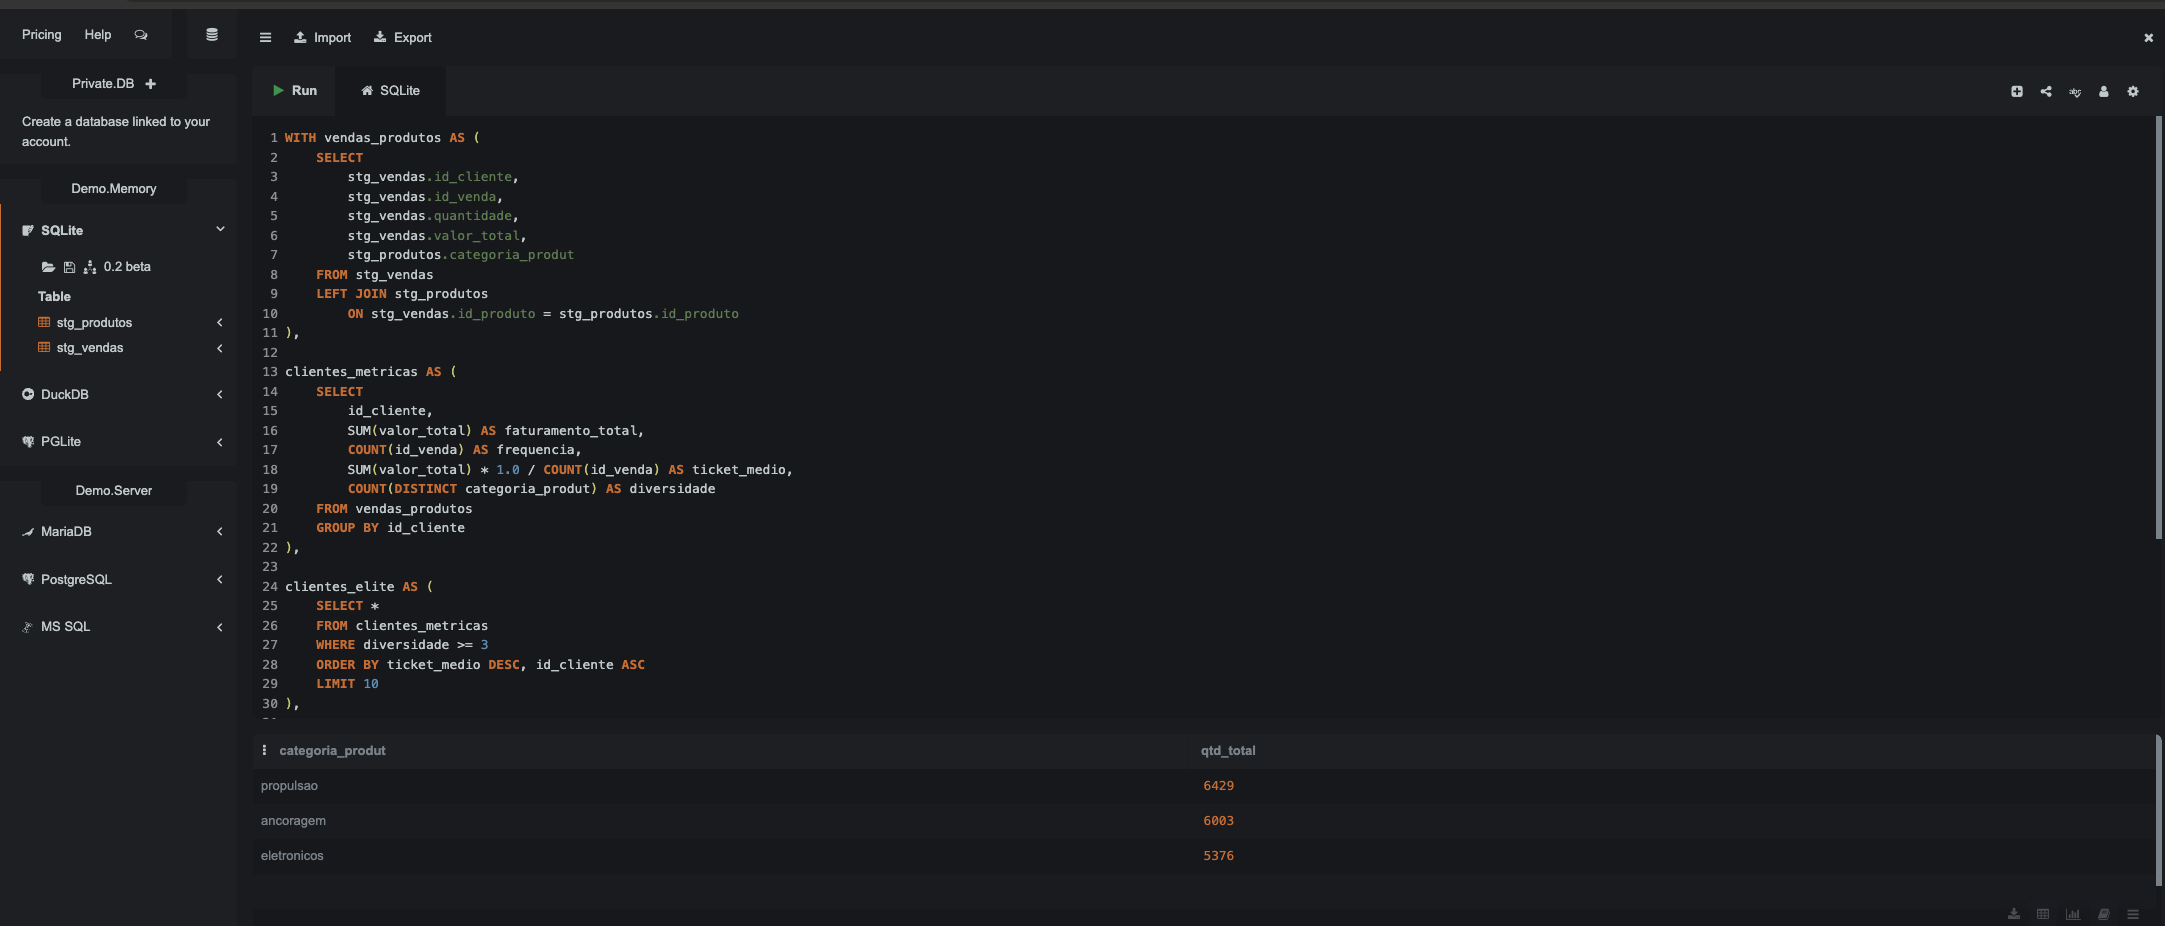

In [32]:
display(Image(filename=IMAGES_PATH / "5_1_codigo.png"))


Questão 5.2 - Validação

Considerando apenas as compras realizadas pelos Top 10
Clientes selecionados (Critério: Maior Ticket Médio com 3 +
categorias): 

Qual foi a categoria de produtos mais
vendida para eles (maior quantidade total de itens)?

Resposta: propulsao


Questão 5.3 - Explique:

1 - Como você realizou a limpeza das categorias?

2 - Qual lógica utilizou para filtrar os clientes com
diversidade mínima?

3 - Como garantiu que a contagem de itens refletisse
apenas os Top 10?

1 - Como você realizou a limpeza das categorias?

Fiz a limpeza das categorias em uma etapa de tratamento dos dados em uma camada staging de dados (todos os códigos estão na pasta notebooks), padronizando todos os valores. Normalizei e padronizei tudo, lowercase, remoção de possíveis inconsistências e uniformizei os nomes das categorias.



2 - Qual lógica utilizou para filtrar os clientes com diversidade mínima?

Calculei a diversidade com a quantidade de categorias diferentes que cada cliente comprou. Usei COUNT(DISTINCT categoria_produt) agrupando por cliente, e depois filtrei apenas os clientes com 3 ou mais categorias, como foi pedido.


3 - Como garantiu que a contagem de itens refletisse apenas os Top 10?

Depois que calculei as métricas por cliente (faturamento total, frequência, ticket médio e diversidade), ordenei os clientes pelo ticket médio em ordem decrescente e para os casos de empate, fiz pelo id_cliente em ordem crescente. Depois, apliquei um LIMIT 10 para saber quais eram os Top 10 clientes.

Para garantir que só esses clientes fossem selecionados na contagem final, fiz um INNER JOIN entre vendas e o subconjunto dos clientes elite. Assim, a agregação das quantidades por categoria considerou apenas as compras desses Top 10 clientes.